## imports

In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')


In [2]:

from ult import *
import multiprocess
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


# agent and task

In [3]:
modelname = 'varyreward67noperoid'
iepoch=22

# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot during training
plot_no_episodes = 555
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
p1p2 = np.array([.6, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)


task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2

thismodel = f'seed{seed}_{modelname}_{iepoch}'
model = PPO.load(f'ycstore/{thismodel}')

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# eval collection -------------------
results = []
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
    return episode

with multiprocess.Pool(processes=8) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))


In [5]:
# process
for episode in all_episode_data:
    # episode['ip'] = ip
    # episode['inode'] = inode
    episode['at_times'] = np.where(
        np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
    episode['at_seq'] = [float(elt[1])
                            for elt in episode['actions']]
    if episode['actions'][-1][0] == 1:
        episode['licktime'] = int(len(episode['states']))
    else:
        episode['lick_licktimetime'] = -1
    episode['trial_len'] = len(episode['actions'])
    results.append(episode)
df = pd.DataFrame(results)

(0.0, 50.0)

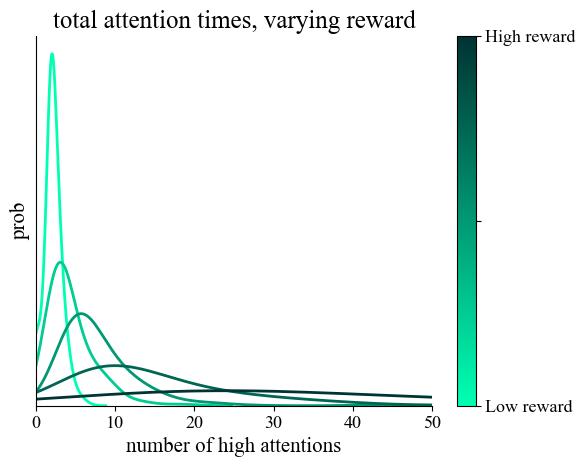

In [6]:
# total attn time dist
fig= plt.figure()
for food_reward_idx in np.arange(len(food_reward_list)):
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    sns.kdeplot([len(a) for a in subdf.at_times],  label=f'food reward={food_reward_list[food_reward_idx]:.0f}, p={p1p2}', bw_adjust=2, common_norm=False, color=rewardcmap(
        np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=pcmap), ax=plt.gca())
ticks = [0, 0.5, 1]
tick_labels = ['Low reward', '', 'High reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)

plt.xlabel('number of high attentions')
plt.ylabel('prob')
plt.title(f'total attention times, varying reward')
# plt.ylim(0,1500)
# plt.legend()
centerax(plt.gca())
plt.yticks([])
plt.xlim(0, 50)
# plt.xticks([0, 15])
# # quicksave('total att time', 'plot sigmoid', fig=fig)
# plt.show()


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/3343085127.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(plotdata, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=1, common_norm=False, color=rewardcmap(


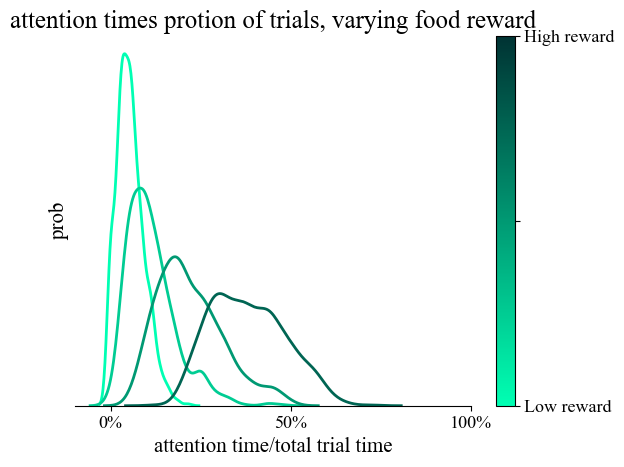

In [7]:
# total attn time dist
fig= plt.figure()
for food_reward_idx in np.arange(len(food_reward_list)):
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    plotdata=[len(a)/b for a,b in zip(subdf.at_times,subdf.trial_len)]
    sns.kdeplot(plotdata, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=1, common_norm=False, color=rewardcmap(
        np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
    
color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=pcmap), ax=plt.gca())
ticks = [0, 0.5, 1]
tick_labels = ['Low reward', '', 'High reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)
# plt.xlabel('number of high attentions')
plt.ylabel('prob')
plt.title(f'attention times protion of trials, varying food reward')
# # plt.ylim(0,1500)
# centerax(plt.gca())
plt.yticks([])
plt.gca().spines['left'].set_visible(False)
# plt.xlim(0, 1)
plt.xticks([0, 0.5, 1], ['0%', '50%', '100%'])
plt.xlabel('attention time/total trial time')
plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/3529398139.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


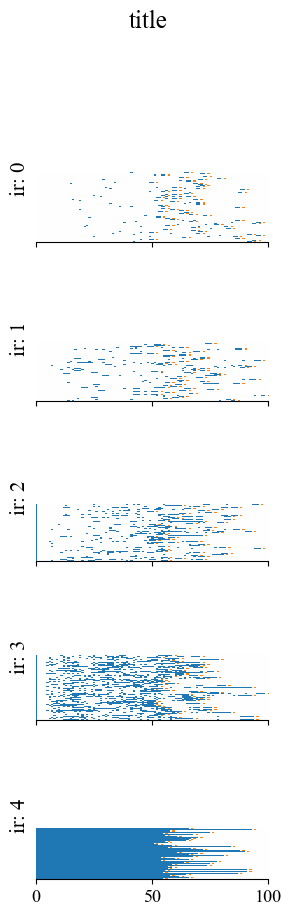

In [8]:
# raster
minlen, maxlen = 50, 100
rasterfig, axs = plt.subplots(len(food_reward_list), 1, figsize=(
        3, len(food_reward_list)*2,), sharex=True, sharey=True)
for food_reward_idx in range(len(food_reward_list)):
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    # df=df[df['at_times'].apply(len) > 0]
    subdf=subdf[subdf.licktime!=-1]
    # df.licktime=df.licktime.astype('int')
    subdf=subdf[~subdf.licktime.isna()]
    if len(subdf)==0: continue
    trial_len = np.array(subdf.trial_len)
    valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
    grid = np.zeros((len(valid_ind), max(trial_len)+2))
    sortind = np.argsort([trial_len[i] for i in valid_ind])
    # att
    plot_data = np.array(subdf.at_times)[valid_ind]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1
    # lick
    plot_data = np.array(subdf.licktime)[valid_ind]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, int(arr)] = 1

    c = axs[food_reward_idx].imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                        aspect='auto', interpolation='none')

    axs[food_reward_idx].set_xticks([0, 50, 100])
    axs[food_reward_idx].set_xlim(0, 100)
    axs[food_reward_idx].set_ylim(0, 300)
    axs[food_reward_idx].set_yticks([])
    axs[food_reward_idx].spines['left'].set_visible(False)
    axs[food_reward_idx].set_ylabel(f'ir: {food_reward_idx} ')
rasterfig.suptitle(f'title')
rasterfig.show()

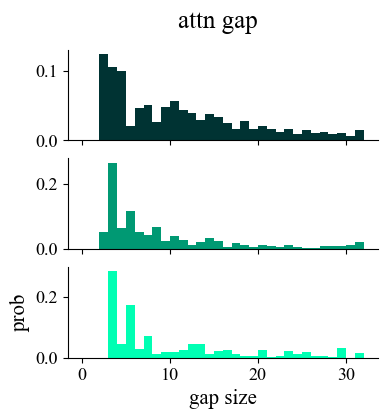

In [9]:

use_reward = [1, 2, 3]
fig, axs = plt.subplots(len(use_reward), 1, figsize=(4, 4), sharex=True)

for food_reward_idx, reward in enumerate(use_reward):
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    gaps=np.concatenate(subdf.at_times.apply(find_gaps).to_list())
    sizes=np.concatenate(subdf.at_times.apply(find_blocksize).to_list())
    axs[len(use_reward)-food_reward_idx-1].hist(gaps, bins=np.arange(33), color=rewardcmap(np.linspace(0, 1, len(use_reward))[food_reward_idx]), density=True, alpha=1)
    # sns.kdeplot(gaps, color=pcmap(np.linspace(0, 1, len(plist))[ip]),bw_adjust=2, common_norm=False) 
plt.suptitle(f'attn gap')
axs[-1].set_xlabel('gap size')
plt.ylabel('prob')
plt.show()




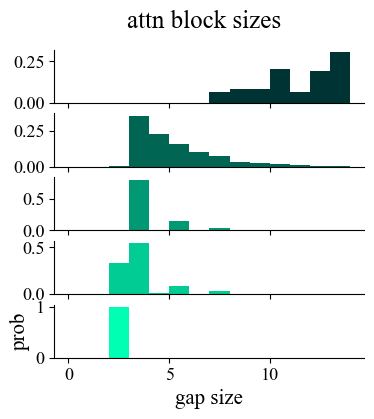

In [10]:

use_reward =[0,1,2,3,4]
fig, axs = plt.subplots(len(use_reward), 1, figsize=(4, 4), sharex=True)

for food_reward_idx, reward in enumerate(use_reward):
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    gaps=np.concatenate(subdf.at_times.apply(find_gaps).to_list())
    sizes=np.concatenate(subdf.at_times.apply(find_blocksize).to_list())
    axs[len(use_reward)-food_reward_idx-1].hist(sizes, bins=np.arange(15), color=rewardcmap(np.linspace(0, 1, len(use_reward))[food_reward_idx]), density=True, alpha=1)
    # sns.kdeplot(gaps, color=pcmap(np.linspace(0, 1, len(plist))[ip]),bw_adjust=2, common_norm=False) 
plt.suptitle(f'attn block sizes')
axs[-1].set_xlabel('gap size')
plt.ylabel('prob')
plt.show()




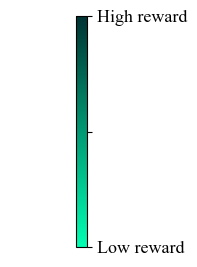

In [11]:
fig, axs = plt.subplots(1,1, figsize=(1,3))
color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=pcmap), ax=plt.gca())
ticks = [0, 0.5, 1]

tick_labels = ['Low reward', '', 'High reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)
ax = plt.gca()  # Get the current axes
for spine in ax.spines.values():
    spine.set_visible(False)
plt.xticks([])
plt.yticks([])
plt.show()

/Users/yc/repo/auditory-foraging-IRC/ult.py:1123: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


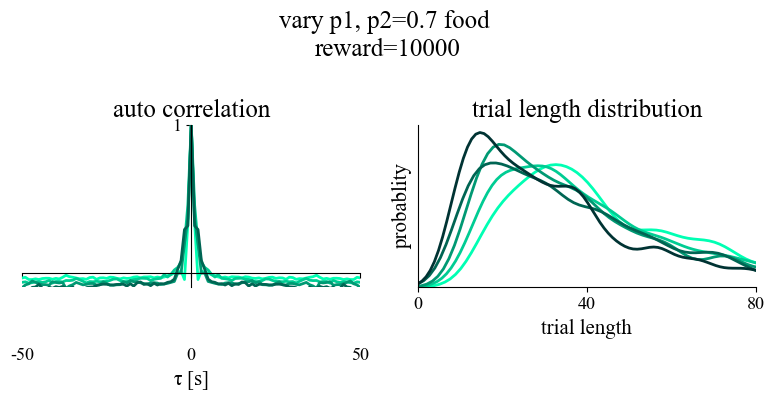

<Figure size 640x480 with 0 Axes>

In [12]:
# autocorr
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
for food_reward_idx in range(len(food_reward_list)):
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    if len(subdf)==0: 
        print(food_reward_idx, 'skfood_reward_idxped')
        continue
    att_seq_list = np.array(subdf.at_seq)
    autocorr, total_counts = empirical_autocorrelation_new(
        att_seq_list, min_no_samples=1111)
    xs = np.arange(0, len(autocorr), 1)
    xs = xs-len(xs)//2
    ax1.plot(xs, autocorr,
                label=f'p:{p1p2}', color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
    sns.kdeplot([len(a) for a in att_seq_list],
                fill=False, bw_adjust=0.5, ax=ax2, color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50)

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_yticks([])
    ax2.set_xlim(0, 80)
    ax2.set_xticks([0, 40, 80])
    ax2.set_title('trial length distribution')

fig.suptitle(
    f'vary p1, p2={p1p2[1]} food \nreward={food_reward_list[food_reward_idx]:.0f}')
fig.tight_layout()
plt.show()

color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=rewardcmap), ax=ax2)
ticks = [0, 0.5, 1]
tick_labels = [f'Low reward={food_reward_list[0]}', '', f'High reward={food_reward_list[-1]}']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)
plt.show()

In [81]:
# # imshow fill between
# vmin,vmax=0,50
# nbin=20
# bins=np.linspace(0,1,nbin)

# for food_reward_idx in range(len(food_reward_list)):
#     bindata=[[] for _ in range(nbin)] 
#     subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
#     sb, nextatt=[],[]
#     for alist, b in zip(subdf.at_times, subdf.beliefs):
#         try:
#             a,b=trialnextatt(alist,b),trialsb(b)  
#             for j in range(len(b)):
#                 thisa,thisb=a[j], b[j]
#                 for i, (s,e) in enumerate(zip(bins, bins[1:])):
#                     if s<thisb<=e:
#                         bindata[i].append(thisa)
#         except:
#             continue

#     mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
#     mu, err=np.array(mu), np.array(err)
#     # plt.errorbar(bins,mu, err)
#     # plt.fill_between(bins,mu-err, mu+err, alpha=0.6, color=rewardcmap(
#     #     np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
#     percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
#     percentile_95 = np.array([np.percentile(data, 95) if data else 0 for data in bindata])
#     lowerr=np.clip(mu-percentile_5, 0,None)
#     higherr=np.clip(percentile_95-mu, 0,None)
#     # plt.errorbar(bins-0.01*food_reward_idx,mu, [lowerr, higherr], color=rewardcmap(
#     #     np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
#     plt.fill_between(bins,lowerr, higherr, alpha=0.6, color=rewardcmap(
#         np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
# plt.colorbar(c)
# plt.xlabel('prob')
# plt.ylabel('gap')
# plt.xticks([0,1],[0,1])
# plt.xlim(0,None)
# plt.ylim(0,None)
# plt.title(f'varying reward, \np:{p1p2},\nnode:{25}')
# # quicksave(f'vary reward {food_reward_idx} np', 'test', fig=fig)
# plt.show()
# plt.close()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/383637963.py:25: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/383637963.py:62: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


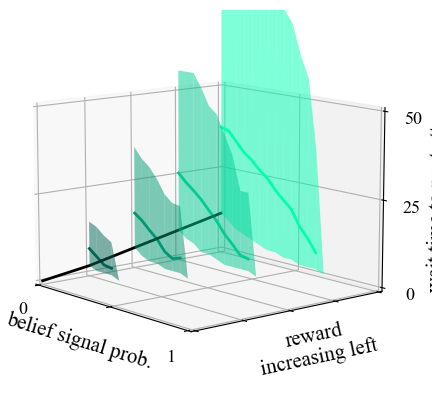

In [124]:
# imshow 3d
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)
plotdata=[] # for plot data

for food_reward_idx in range(len(food_reward_list))[:]:
    bindata=[[] for _ in range(nbin)] 
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    sb, nextatt=[],[]
    for alist, b in zip(subdf.at_times, subdf.beliefs):
        try:
            a,b=trialnextatt(alist,b),trialsb(b)  
            for j in range(len(b)):
                thisa,thisb=a[j], b[j]
                for i, (s,e) in enumerate(zip(bins, bins[1:])):
                    if thisa>0 and s<thisb<=e:
                        bindata[i].append(thisa)
        except:
            continue

    mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
    mu, err=np.array(mu), np.array(err)
    # plt.errorbar(bins,mu, err)
    # plt.fill_between(bins,mu-err, mu+err, alpha=0.6, color=rewardcmap(
    #     np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
    percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
    percentile_95 = np.array([np.percentile(data, 95) if data else 0 for data in bindata])
    lowerr=np.clip(mu-percentile_5, 0,None)
    higherr=np.clip(percentile_95-mu, 0,None)
    # plt.errorbar(bins-0.01*food_reward_idx,mu, [lowerr, higherr], color=rewardcmap(
    #     np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
    plotdata.append([percentile_5, percentile_95, mu])
# print(plotdata)
y_values = np.arange(len(food_reward_list)-1, -1,-1)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')
for y, (y1, y2, mu) in zip(y_values, plotdata):
    verts = []
    for i in range(len(bins) - 1):
        verts.append([(bins[i], y, y1[i]), (bins[i+1], y, y1[i+1]), (bins[i+1], y, y2[i+1]), (bins[i], y, y2[i])])

    poly = Poly3DCollection(verts, facecolors=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[len(food_reward_list)-y-1], alpha=0.5, edgecolors='none')
    ax.add_collection3d(poly)
    ax.plot(bins,np.zeros_like(bins)+y, mu,color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[len(food_reward_list)-y-1])

ax.plot(np.zeros_like(y_values),y_values,[low[0][0] for low in plotdata] ,color='black')

ax.set_xlim(0, 1)
ax.set_ylim(0, 2)
ax.set_zlim(0, 50)
ax.set_xlabel('belief signal prob.',labelpad=1)
ax.set_yticks(np.arange(5),[])
ax.set_zticks([0,25,50])
ax.set_xticks([0,0.5,1],['0','','1'])
ax.set_ylabel('reward\nincreasing left',labelpad=1)
ax.set_zlabel('wait time to next attn.',labelpad=1)

plt.tight_layout()
ax.view_init(azim=-40, elev=11) 
quicksave('vary reward 3d np','plot wait time', fig=fig)
plt.show()


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/2565403988.py:26: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


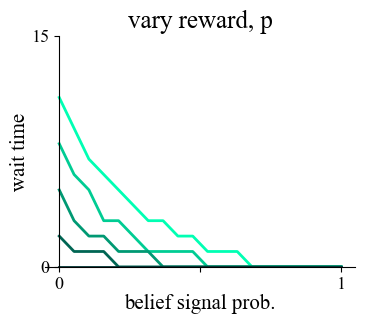

In [149]:
# imshow 2d lower tri
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)
plotdata=[] # for plot data
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(111)
for food_reward_idx in range(len(food_reward_list))[:]:
    bindata=[[] for _ in range(nbin)] 
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    sb, nextatt=[],[]
    for alist, b in zip(subdf.at_times, subdf.beliefs):
        try:
            a,b=trialnextatt(alist,b),trialsb(b)  
            for j in range(len(b)):
                thisa,thisb=a[j], b[j]
                for i, (s,e) in enumerate(zip(bins, bins[1:])):
                    if thisa>0 and s<thisb<=e:
                        bindata[i].append(thisa)
        except:
            continue

    mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
    mu, err=np.array(mu), np.array(err)
    percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
    ax.plot(bins, percentile_5,color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
    centerax(ax)
ax.set_ylim(0, 2)
ax.set_xlabel('belief signal prob.',labelpad=1)
ax.set_ylabel('wait time',labelpad=1)
ax.set_yticks([0,15])
ax.set_xticks([0,0.5,1],['0','','1'])
ax.set_title('vary reward, p')

quicksave('vary reward waittime p','plot wait time', fig=fig)
plt.show()

In [80]:
# # imshow line
# vmin,vmax=0,50
# nbin=20
# bins=np.linspace(0,1,nbin)

# for food_reward_idx in range(len(food_reward_list)):
#     bindata=[[] for _ in range(nbin)] 
#     subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
#     sb, nextatt=[],[]
#     for alist, b in zip(subdf.at_times, subdf.beliefs):
#         try:
#             a,b=trialnextatt(alist,b),trialsb(b)  
#             for j in range(len(b)):
#                 thisa,thisb=a[j], b[j]
#                 for i, (s,e) in enumerate(zip(bins, bins[1:])):
#                     if s<thisb<=e:
#                         bindata[i].append(thisa)
#         except:
#             continue
#     mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
#     mu, err=np.array(mu), np.array(err)
#     # plt.errorbar(bins-0.01*food_reward_idx,mu, err, color=rewardcmap(
#         # np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
#     percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
#     percentile_95 = np.array([np.percentile(data, 95) if data else 0 for data in bindata])
#     lowerr=np.clip(mu-percentile_5, 0,None)
#     higherr=np.clip(percentile_95-mu, 0,None)
#     plt.errorbar(bins-0.01*food_reward_idx,mu, [lowerr, higherr], color=rewardcmap(
#         np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])

# plt.colorbar(c)
# plt.xlabel('prob')
# plt.ylabel('gap')
# plt.xticks([0,1],[0,1])
# plt.xlim(0,None)
# plt.ylim(0,None)
# plt.title(f'varying reward, \np:{p1p2},\nnode:{25}')
# # quicksave(f'vary reward {food_reward_idx} np', 'test', fig=fig)
# plt.show()
# plt.close()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:27: RuntimeWarning: invalid value encountered in divide
  col=col/np.sum(col)


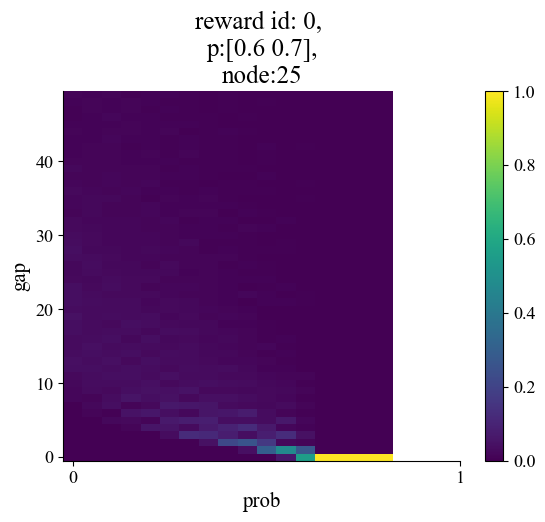

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:27: RuntimeWarning: invalid value encountered in divide
  col=col/np.sum(col)


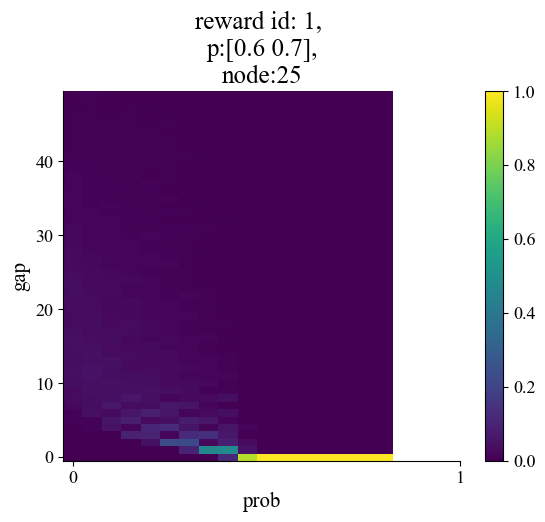

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:27: RuntimeWarning: invalid value encountered in divide
  col=col/np.sum(col)


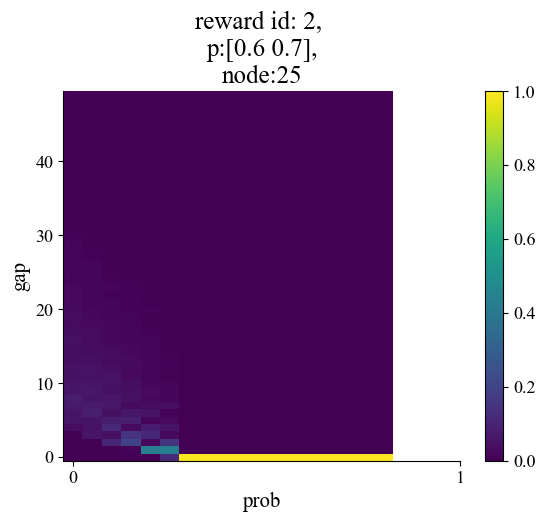

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:27: RuntimeWarning: invalid value encountered in divide
  col=col/np.sum(col)


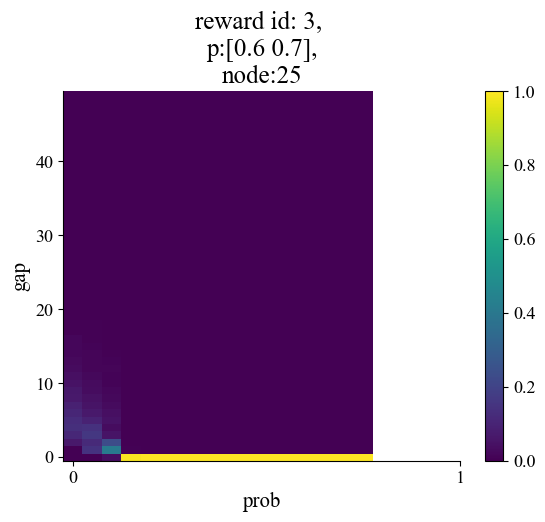

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:27: RuntimeWarning: invalid value encountered in divide
  col=col/np.sum(col)


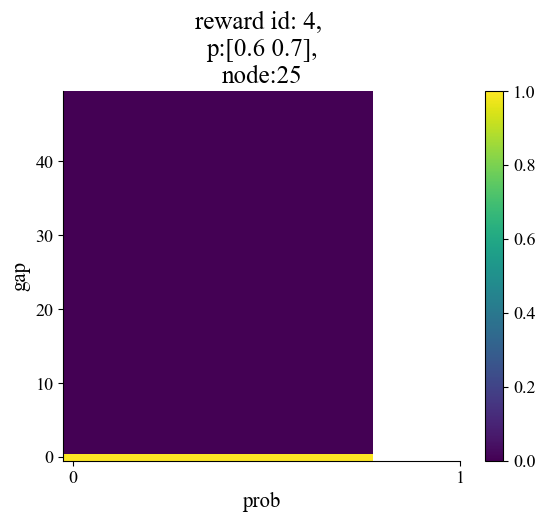

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:63: RuntimeWarning: invalid value encountered in divide
  col=col/np.sum(col)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:66: RuntimeWarning: divide by zero encountered in log
  grid=np.log(grid)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:63: RuntimeWarning: invalid value encountered in divide
  col=col/np.sum(col)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:66: RuntimeWarning: divide by zero encountered in log
  grid=np.log(grid)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:63: RuntimeWarning: invalid value encountered in divide
  col=col/np.sum(col)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.py:66: RuntimeWarning: divide by zero encountered in log
  grid=np.log(grid)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1880/1224193688.p

In [15]:
# imshow
vmin,vmax=0,50
nbin=20

for food_reward_idx in range(len(food_reward_list)):
    grid=np.zeros((vmax, nbin)) # 50, 10
    bins=np.linspace(0,1,nbin)
    bindata=[[] for _ in range(nbin)] 
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    sb, nextatt=[],[]
    for alist, b in zip(subdf.at_times, subdf.beliefs):
        try:
            a,b=trialnextatt(alist,b),trialsb(b)  
            for j in range(len(b)):
                thisa,thisb=a[j], b[j]
                for i, (s,e) in enumerate(zip(bins, bins[1:])):
                    if s<thisb<=e:
                        bindata[i].append(thisa)
        except:
            continue
    for i in range(nbin):
        count=Counter(bindata[i])
        col=[]
        for j in range(vmin, vmax):
            col.append(count[j])
        col=np.array(col)
        col=col/np.sum(col)
        grid[:,i]=col
    fig=plt.figure()
    # grid=np.log(grid)
    c=plt.imshow(grid,aspect='auto', origin='lower')
    plt.colorbar(c)
    plt.xlabel('prob')
    plt.ylabel('gap')
    plt.xticks([0,nbin],[0,1])
    plt.title(f'reward id: {food_reward_idx}, \np:{p1p2},\nnode:{25}')
    # quicksave(f'vary reward {food_reward_idx} np', 'test', fig=fig)
    plt.show()
    plt.close()

for food_reward_idx in range(len(food_reward_list)):
    grid=np.zeros((vmax, nbin)) # 50, 10
    bins=np.linspace(0,1,nbin)
    bindata=[[] for _ in range(nbin)] 
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    sb, nextatt=[],[]
    for alist, b in zip(subdf.at_times, subdf.beliefs):
        try:
            a,b=trialnextatt(alist,b),trialsb(b)  
            for j in range(len(b)):
                thisa,thisb=a[j], b[j]
                for i, (s,e) in enumerate(zip(bins, bins[1:])):
                    if s<thisb<=e:
                        bindata[i].append(thisa)
        except:
            continue
    for i in range(nbin):
        count=Counter(bindata[i])
        col=[]
        for j in range(vmin, vmax):
            col.append(count[j])
        col=np.array(col)
        col=col/np.sum(col)
        grid[:,i]=col
    fig=plt.figure()
    grid=np.log(grid)
    c=plt.imshow(grid,aspect='auto', origin='lower')
    plt.colorbar(c)
    plt.xlabel('prob')
    plt.ylabel('gap')
    plt.xticks([0,nbin],[0,1])
    plt.title(f'reward id: {food_reward_idx}, \np:{p1p2},\nnode:{25}')
    # quicksave(f'vary reward {food_reward_idx} np log', 'test', fig=fig)
    # plt.show()
    plt.close()
